# DP-SGD against its two ℓ₁-projected counterparts, on Criteo

This notebook compares DP-SGD (Abadi et al., *Deep Learning with Differential
Privacy*, 2016, [arXiv:1607.00133](https://arxiv.org/abs/1607.00133)) against
the same run with an ℓ₁ projection inserted at the optimizer seam, on Criteo
click-through data at **ε = 3, δ = 1e-6** over 2,000 steps. Both projections
come from Ghazi, Guzmán, Kamath, Kumar and Manurangsi, *Differentially Private
Optimization with Sparse Gradients*, 2024: `l1_projected` constrains the
**iterates**, so every step lands inside one global ℓ₁ ball, while
`l1_projected_estimate` constrains the **estimate**, projecting the released
gradient into the ball and descending along that.

What is fixed across every arm:

- the same per-sample loss, `per_sample_bce_loss`;
- the same model and the **same initialization**, `init_params(jax.random.key(0), d)`;
- the same data, the same split, the same evaluation set, the same threshold rule;
- the same seeds — noise `jax.random.key(1)`, sampling `np.random.default_rng(2)`,
  drawn fresh for every arm;
- the same 2,000 optimizer steps and the same σ, so every arm carries the
  identical ε.

**The one thing that differs between arms is the `updates.Optimizer` object
handed to `train`**, enforced below by a keyword-only runner that takes the
optimizer and nothing else.

Imports and the constants every run depends on, all named before any of them
is used.

In [15]:
import time
from typing import NamedTuple

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from dimma.accounting.sampling import (
    PoissonGaussianSchedule,
    calibrate_noise_multiplier,
    poisson_gaussian_epsilon,
)
from dimma.algorithms.dp_sgd import train as dp_sgd
from dimma.core import pytree, updates
from dimma.datasets.criteo import load_criteo
from dimma.metrics.calibration import (
    calibration_ratio,
    expected_calibration_error,
)
from dimma.metrics.scoring import log_loss, normalized_entropy
from dimma.models.logreg import forward, init_params
from dimma.models.losses import per_sample_bce_loss
from dimma.transforms.projection import l1_projected, l1_projected_estimate

# The budget, fixed before anything is fitted.
TARGET_EPSILON = 3.0
TARGET_DELTA = 1e-6

# The step budget. Every arm takes exactly this many optimizer steps, and this
# is the composition count sigma is calibrated against.
STEPS = 2_000

# Algorithm 1's L, C and eta. Held identical across every arm.
EXPECTED_BATCH_SIZE = 1024
CLIP_NORM = 5.0
LEARNING_RATE = 0.1

N_BINS = 15    # equal-mass bins for the ECE

# Three streams, three seeds. The initialization is shared by every arm; the
# noise and sampling streams are re-created fresh for each arm so that two arms
# see the same draws.
INIT_SEED, NOISE_SEED, SAMPLING_SEED = 0, 1, 2

DEVICE = "gpu" if any(d.platform == "gpu" for d in jax.devices()) else "cpu"
print(f"jax devices: {jax.devices()}  ->  DEVICE = {DEVICE!r}")

jax devices: [CudaDevice(id=0)]  ->  DEVICE = 'gpu'


## 1. The data

All 39 Criteo features, standardized, on the deterministic `seed=0` split.

In [16]:
split = load_criteo(features="all", preprocess=True, standardize=True,
                    download=False, seed=0, device=DEVICE,
                    feature_norm_bound=None)

n_train, n_features = split.x_train.shape
D_TOTAL = n_features + 1          # 39 weights + the bias, counted globally

X_TEST = split.x_test
Y_TEST = np.asarray(split.y_test, dtype=np.float64)

train_base_rate = float(split.y_train.mean())
test_base_rate = float(split.y_test.mean())

print(f"train {split.x_train.shape}   test {split.x_test.shape}")
print(f"parameters: {n_features} weights + 1 bias = {D_TOTAL}")
print(f"label base rate: {train_base_rate:.4f} train, "
      f"{test_base_rate:.4f} test")
print(f"PR-AUC floor (a random ranking scores the base rate): "
      f"{test_base_rate:.4f}")
print(f"arrays live on: {list(X_TEST.devices())}")
print()
# The key is written only when a bound was actually enforced, so its
# absence is the record that none was.
print(f"enforced feature norm bound R = "
      f"{split.metadata.get('feature_norm_bound', 'none enforced')}")
print()
print(split.metadata["preprocessing"])

train (800000, 39)   test (200000, 39)
parameters: 39 weights + 1 bias = 40
label base rate: 0.2510 train, 0.2520 test
PR-AUC floor (a random ranking scores the base rate): 0.2520
arrays live on: [CudaDevice(id=0)]

enforced feature norm bound R = none enforced

39 features. I1-I13: NaN filled with the train-split median, clipped below at 0, log1p — the fill and the clip are no-ops on stored values that carry neither NaN nor negatives, and log1p acts on [0, 1]. C1-C26: each category ID replaced by that category's relative frequency in the train split, with categories unseen in training encoded as 0.0. Every column then standardized by the train-split mean and standard deviation.


### The caveats that travel with every ε below

- The **preprocessing statistics** — medians, category frequencies, means and
  standard deviations — are fitted on the training split and accounted for in
  no budget (ADR-0008).
- **The ε covers the training loop only.** Nothing here is tuned: `C`, `η` and
  `L` are taken as given, so there is no unaccounted hyperparameter search. The
  radii in section 3 are the one quantity read off a trained model.
- **Test evaluation sits outside the loop by design**: `train` returns
  parameters and no metrics, so the loop is not in a position to leak them.

## 2. Calibrating for 2,000 steps

`calibrate_noise_multiplier` runs the accountant backwards: given a target
`(ε, δ)` and the shape of the run, it returns the smallest noise multiplier
meeting the budget. It takes a *builder* — candidate multiplier to the release
schedules a run would have at that multiplier — and plain DP-SGD has exactly
one schedule, so the builder returns a single-entry list.
`poisson_gaussian_epsilon` prices the run forwards at the multiplier that came
back, and the two are asserted consistent.

`T` is the load-bearing constraint: **the step count the calibration assumes is
the step count every arm actually takes.** `clip_norm` does not enter —
sensitivity is `S = C` by construction and the noise scales with it (`σ·C`), so
the multiplier is the same at every `C`. **The ε is RDP's** (ADR-0011), held
fixed at `method="rdp"` throughout, which is the property a comparison needs.

In [17]:
q = EXPECTED_BATCH_SIZE / n_train

t0 = time.time()
SIGMA = calibrate_noise_multiplier(
    lambda multiplier: [PoissonGaussianSchedule(q, multiplier, STEPS)],
    TARGET_EPSILON, TARGET_DELTA,
)
spent = poisson_gaussian_epsilon(q, SIGMA, STEPS, TARGET_DELTA)
assert spent <= TARGET_EPSILON + 1e-9

print(f"q = L / n = {EXPECTED_BATCH_SIZE} / {n_train:,} = {q:.6f}")
print(f"sigma = {SIGMA:.6f}")
print(f"epsilon spent = {spent:.6f} at delta = {TARGET_DELTA} "
      f"over {STEPS:,} steps  (method='rdp')")
print(f"\ncalibrated in {time.time() - t0:.1f}s")

q = L / n = 1024 / 800,000 = 0.001280
sigma = 0.638442
epsilon spent = 2.999997 at delta = 1e-06 over 2,000 steps  (method='rdp')

calibrated in 0.2s


### Reading the calibration

σ = 0.638442 at q = 0.001280 over 2,000 steps buys ε = 2.999997 — the search
returns the smallest multiplier meeting the budget, so ε lands just under 3
rather than on it. Every arm below runs at this σ and therefore carries this ε
unchanged: **a projection applied after the mechanism releases its estimate is
post-processing and cannot increase the cost.**

## 3. The control, and where the radii come from

The runner is keyword-only and takes the optimizer alone. Everything else —
initialization, data, both seeds, `STEPS`, `L`, `C`, σ — is closed over, so
"the arms differ only in the optimizer" is a property of the code rather than a
claim in prose.

Every arm is scored on **log-loss**, the objective it descends; **normalized
entropy** and the **calibration ratio**; **ECE** at 15 equal-mass bins, because
per-example clipping is the documented cause of miscalibration under DP; and
**PR-AUC**, the ranking read, floored at the base rate. `pr_curve` is a
notebook-local helper by decision — `dimma.metrics` offers no metric that reads
rank alone.

**The threshold is a choice, not a discovery.** Predictions are `probs >
THRESHOLD` with `THRESHOLD` the *training-split* base rate. It is
strictly-greater, which matters for exactly one row: a constant predictor whose
output equals the threshold predicts nothing, so its precision is undefined
(`tp + fp == 0`) and prints as `0.0000`.

`‖θ‖₁` and the non-zero count are taken over the **ravelled pytree** — weights
and bias together, 40 numbers — because that is the object the transforms
project: one global ball across all leaves, not one per leaf.

In [18]:
class Eval(NamedTuple):
    """What one arm is scored on. All on the test split."""

    loss: float
    ne: float
    ece: float
    cal: float
    pr_auc: float
    precision: float
    recall: float
    l1: float
    nnz: int


THRESHOLD = train_base_rate


def flat(params):
    """The parameters as one vector, in the order the transforms see them."""
    return np.concatenate(
        [np.asarray(v).ravel() for v in jax.tree_util.tree_leaves(params)]
    )


def l1_norm(params) -> float:
    return float(np.abs(flat(params)).sum())


def nnz(params) -> int:
    return int((flat(params) != 0.0).sum())


def l1_norm_traced(tree):
    """`l1_norm` for a pytree of tracers, for the recorder in section 4."""
    return sum(jnp.abs(v).sum() for v in jax.tree_util.tree_leaves(tree))


def pr_curve(probs, y):
    """Precision and recall at every cut, plus average precision (PR-AUC).

    Sort by score descending and integrate precision over recall at every
    positive. Local by decision rather than by omission - see above.
    """
    order = np.argsort(-probs)
    hits = y[order]
    positives = hits.sum()
    tp = np.cumsum(hits)
    precision = tp / np.arange(1, len(hits) + 1)
    recall = tp / positives
    pr_auc = float((precision * hits).sum() / positives)
    return precision, recall, pr_auc


def probabilities_of(params):
    """Test-split probabilities. `forward` is a single-example function."""
    logits = np.asarray(jax.vmap(forward, in_axes=(None, 0))(params, X_TEST))
    return np.asarray(jax.nn.sigmoid(jnp.asarray(logits)), dtype=np.float64)


def score(probs, params) -> Eval:
    """Score one set of test probabilities at the fixed threshold."""
    pred = probs > THRESHOLD
    truth = Y_TEST > 0.5
    tp = int((pred & truth).sum())
    fp = int((pred & ~truth).sum())
    fn = int((~pred & truth).sum())
    return Eval(
        loss=log_loss(probs, Y_TEST),
        ne=normalized_entropy(probs, Y_TEST),
        ece=expected_calibration_error(probs, Y_TEST, n_bins=N_BINS),
        cal=calibration_ratio(probs, Y_TEST),
        pr_auc=pr_curve(probs, Y_TEST)[2],
        # undefined precision prints as 0.0000; see the note above
        precision=tp / (tp + fp) if tp + fp else 0.0,
        recall=tp / (tp + fn) if tp + fn else 0.0,
        l1=l1_norm(params) if params is not None else 0.0,
        nnz=nnz(params) if params is not None else 0,
    )


def evaluate(params) -> Eval:
    return score(probabilities_of(params), params)


def run_arm(*, optimizer):
    """One arm. The optimizer is the only thing a caller may vary."""
    params = init_params(jax.random.key(INIT_SEED), n_features)
    return dp_sgd.train(
        per_sample_bce_loss, params, optimizer,
        split.x_train, split.y_train,
        jax.random.key(NOISE_SEED), np.random.default_rng(SAMPLING_SEED),
        steps=STEPS, expected_batch_size=EXPECTED_BATCH_SIZE,
        clip_norm=CLIP_NORM, noise_multiplier=SIGMA,
    )

The control is plain DP-SGD, `updates.sgd(0.1)` with nothing wrapped around it:
the first row of section 5's table, and the source of one of the three radii
this cell fixes.

- `RADIUS_ITER = 0.5 × ‖θ_control‖₁` — **read off the control**, deliberately
  half its norm so the ball is guaranteed to bind. The one quantity here
  derived from a trained model, and a choice about what to illustrate rather
  than a tuned hyperparameter.
- `RADIUS_PAPER = C·√d` — Ghazi et al.'s prescription for records ℓ₂-bounded by
  `C` and `d`-sparse, evaluated at this problem's `C` and `d`. Fixed a priori.
- `RADIUS_BINDING = 0.19` — hardcoded, chosen to force the estimate-side
  projection to bind. Section 4 measures the quantity that justifies it.

In [19]:
t0 = time.time()
control_params = run_arm(optimizer=updates.sgd(LEARNING_RATE))
CONTROL = evaluate(control_params)
print(f"control run: {time.time() - t0:.1f}s\n")

RADIUS_WIDE = 1e6                                   # effectively no constraint
RADIUS_ITER = 0.5 * CONTROL.l1                      # read off the control
RADIUS_PAPER = CLIP_NORM * np.sqrt(D_TOTAL)         # Ghazi et al.'s C*sqrt(d)
RADIUS_BINDING = 0.19                               # PR #24's, hardcoded

print(f"control test log-loss {CONTROL.loss:.4f}   PR-AUC {CONTROL.pr_auc:.4f}"
      f"   ECE {CONTROL.ece:.4f}")
print(f"control ||theta||_1 = {CONTROL.l1:.4f}   "
      f"non-zero {CONTROL.nnz} of {D_TOTAL}")
print()
print(f"RADIUS_WIDE    = {RADIUS_WIDE:g}       (no constraint, both sides)")
print(f"RADIUS_ITER    = {RADIUS_ITER:.4f}   (0.5 x control ||theta||_1)")
print(f"RADIUS_PAPER   = {RADIUS_PAPER:.4f}  (C x sqrt({D_TOTAL}))")
print(f"RADIUS_BINDING = {RADIUS_BINDING}      (PR #24's, forced to bind)")

control run: 8.0s

control test log-loss 0.5142   PR-AUC 0.4475   ECE 0.0110
control ||theta||_1 = 5.2602   non-zero 40 of 40

RADIUS_WIDE    = 1e+06       (no constraint, both sides)
RADIUS_ITER    = 2.6301   (0.5 x control ||theta||_1)
RADIUS_PAPER   = 31.6228  (C x sqrt(40))
RADIUS_BINDING = 0.19      (PR #24's, forced to bind)


### Reading the control

Test log-loss 0.5142 at ε = 3, against a constant predictor's 0.5645 (section
5's last row). All 40 parameters are non-zero, so any zero below is produced by
a projection rather than inherited.

`‖θ_control‖₁ = 5.2602` is the number the rest of the notebook is scaled
against, and it already sits six times inside `RADIUS_PAPER = 31.62` — the ball
the paper prescribes for the *estimate*, which section 4 shows is two orders of
magnitude wider still.

## 4. What the mechanism actually releases

The estimate-side projection can only matter if its ball is narrower than what
DP-SGD releases, so that norm is measured here rather than assumed. `train`
hands back parameters and nothing else, so the quantity is instrumented at the
seam with a wrapper that records and does not touch. **The wrapper is
notebook-local, is post-processing, and makes no privacy claim.**

One mechanical trap, stated because the code looks odd without it: `train` jits
its step with the optimizer *baked into the traced function*, so a plain Python
`list.append` would fire once, at trace time, and record a single tracer;
`jax.debug.callback(..., ordered=True)` is what actually runs every step, in
step order. The wrapper is placed **outermost**, so one recorder yields both
quantities — the estimate DP-SGD released *before* any projection, and
`params + increment` *after* it. The cell below asserts the recorded control is
bit-identical to section 3's, which is the evidence that the instrumentation is
inert.

In [20]:
def recording(optimizer, released, iterate):
    """`optimizer`, plus two host-side records. Changes nothing it wraps."""

    def update_fn(estimate, state, params=None):
        # ordered=True, and a callback rather than a bare append: the step is
        # jitted with the optimizer inside it, so an append would fire at
        # trace time only. See the note above.
        jax.debug.callback(released.append, l1_norm_traced(estimate),
                           ordered=True)
        increment, new_state = optimizer.update(estimate, state, params)
        jax.debug.callback(iterate.append,
                           l1_norm_traced(pytree.add(params, increment)),
                           ordered=True)
        return increment, new_state

    return updates.Optimizer(optimizer.init, update_fn)


released_control, iterate_control = [], []
t0 = time.time()
recorded_params = run_arm(optimizer=recording(
    updates.sgd(LEARNING_RATE), released_control, iterate_control))

# The instrumentation is inert, and this is the check rather than the promise.
assert jax.tree_util.tree_all(jax.tree_util.tree_map(
    lambda a, b: bool((a == b).all()), control_params, recorded_params))
assert len(released_control) == STEPS == len(iterate_control)

RELEASED = np.array([float(v) for v in released_control])
TRAJECTORY_CONTROL = np.array([float(v) for v in iterate_control])

tail = RELEASED[-200:]
print(f"recorded control: {time.time() - t0:.1f}s, "
      f"{len(released_control):,} callbacks, "
      f"parameters bit-identical to section 3's control\n")
print(f"||g~||_1 over the whole run: min {RELEASED.min():.4f}, "
      f"max {RELEASED.max():.4f}")
print(f"||g~||_1 over the last 200 steps: "
      f"mean {tail.mean():.4f} +- {tail.std():.4f} (sd)")
print()
print(f"paper radius   C*sqrt(d) = {RADIUS_PAPER:.2f}  ->  "
      f"{RADIUS_PAPER / tail.mean():.0f}x the released norm "
      f"({np.log10(RADIUS_PAPER / tail.mean()):.2f} decades)")
print(f"forced radius            = {RADIUS_BINDING}  ->  "
      f"{tail.mean() / RADIUS_BINDING:.1f}x below the released norm")

recorded control: 9.6s, 2,000 callbacks, parameters bit-identical to section 3's control

||g~||_1 over the whole run: min 0.2159, max 1.3649
||g~||_1 over the last 200 steps: mean 0.4083 +- 0.0641 (sd)

paper radius   C*sqrt(d) = 31.62  ->  77x the released norm (1.89 decades)
forced radius            = 0.19  ->  2.1x below the released norm


The same thing over the run, on a log axis because the two reference radii are
nearly four decades apart.

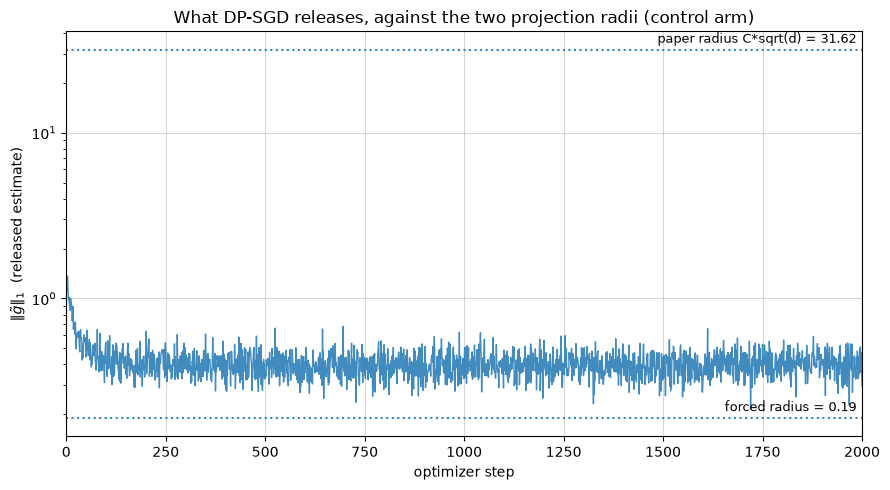

In [21]:
fig, axis = plt.subplots(figsize=(9, 5))

axis.plot(np.arange(1, STEPS + 1), RELEASED,
          linewidth=1.0, alpha=0.85)

for radius, label in ((RADIUS_PAPER, f"paper radius C*sqrt(d) = "
                                     f"{RADIUS_PAPER:.2f}"),
                      (RADIUS_BINDING, f"forced radius = {RADIUS_BINDING}")):
    axis.axhline(radius, linestyle=":", alpha=0.9)
    axis.annotate(label, xy=(STEPS, radius), xytext=(-4, 5),
                  textcoords="offset points", ha="right",
                  fontsize=9)

axis.set_yscale("log")
axis.set_xlabel("optimizer step")
axis.set_ylabel(r"$\|\tilde{g}\|_1$  (released estimate)")
axis.set_xlim(0, STEPS)
axis.set_title("What DP-SGD releases, against the two projection radii "
               "(control arm)")
axis.grid(alpha=0.5)
fig.tight_layout()
plt.show()

### Reading the released norms

The released estimate settles at `‖g̃‖₁ ≈ 0.41 ± 0.06` and never once in 2,000
steps exceeds 1.37, against the paper's radius of 31.62. **The ball is roughly
77 times too wide to ever touch what this mechanism releases — 1.9 decades of
headroom — so the projection at that radius is arithmetically the identity
map.**

The premise behind `C·√d` is Lemma 3.1's: per-example gradients that are
sparse, so the projection strips dense noise while the sparse signal survives.
Here `d = 40`, every feature is dense after frequency encoding and
standardization, and the per-example gradient of a logistic model,
`(σ(x·w) − y)·x`, is as dense as `x`. `RADIUS_BINDING = 0.19` is the answer to
that: it sits about 2.1× *below* the typical released norm, so the projection
is forced to do something.

## 5. The six arms, one table

Six arms, one `run_arm` call each, the same seeds, the same σ and therefore the
same ε; the only thing that varies is the optimizer object.

| arm | optimizer |
|---|---|
| control | `updates.sgd(0.1)` |
| iterate-projected, wide | `l1_projected(sgd, 1e6)` |
| iterate-projected, binding | `l1_projected(sgd, 2.6301)` |
| estimate-projected, wide | `l1_projected_estimate(sgd, 1e6)` |
| estimate-projected, paper | `l1_projected_estimate(sgd, 31.62)` |
| estimate-projected, forced | `l1_projected_estimate(sgd, 0.19)` |

The two wide arms are the identity check: at radius 1e6 neither ball can bind,
so both must reproduce the control exactly, and a difference would mean a
wrapper is doing something other than projecting.

A **constant predictor** closes the table as the reference row, predicting the
training base rate for every record. Its **PR-AUC is entered as the test base
rate** — every score is tied, so an average precision computed over the sorted
array reports the arrival order of ties rather than a ranking, and the printed
value below shows what that artifact reads. Its **precision is `0.0000` because
it is undefined**, and its **`‖θ‖₁` and non-zero count are zero**: it has no
parameters.

In [22]:
ARMS = [
    ("iterate-projected,  r = 1e6", l1_projected, RADIUS_WIDE),
    (f"iterate-projected,  r = {RADIUS_ITER:.4f}", l1_projected, RADIUS_ITER),
    ("estimate-projected, r = 1e6", l1_projected_estimate, RADIUS_WIDE),
    (f"estimate-projected, r = {RADIUS_PAPER:.2f}", l1_projected_estimate,
     RADIUS_PAPER),
    (f"estimate-projected, r = {RADIUS_BINDING}", l1_projected_estimate,
     RADIUS_BINDING),
]

t0 = time.time()
RESULTS = {"DP-SGD (control)": CONTROL}
for name, wrap, radius in ARMS:
    RESULTS[name] = evaluate(
        run_arm(optimizer=wrap(updates.sgd(LEARNING_RATE), radius)))

constant_probs = np.full(len(Y_TEST), train_base_rate)
tied_pr_auc = pr_curve(constant_probs, Y_TEST)[2]
CONSTANT = score(constant_probs, None)._replace(pr_auc=test_base_rate)
print(f"five arms in {time.time() - t0:.1f}s\n")

header = (f"{'arm':<31}{'log-loss':>9}{'NE':>8}{'ECE':>8}{'cal':>8}"
          f"{'PR-AUC':>8}{'prec':>7}{'recall':>8}{'||w||_1':>9}{'non-zero':>10}")
print(header)
print("-" * len(header))
for name, r in list(RESULTS.items()) + [("constant (base rate)", CONSTANT)]:
    if name == "constant (base rate)":
        print("-" * len(header))
    print(f"{name:<31}{r.loss:9.4f}{r.ne:8.4f}{r.ece:8.4f}{r.cal:8.4f}"
          f"{r.pr_auc:8.4f}{r.precision:7.4f}{r.recall:8.4f}{r.l1:9.4f}"
          f"{r.nnz:>6} of {D_TOTAL}")

print(f"\nthreshold: probs > {THRESHOLD:.4f} (the training base rate)")
print(f"constant-row PR-AUC entered as the test base rate "
      f"{test_base_rate:.4f}; average precision over the tied scores would "
      f"read {tied_pr_auc:.4f}, which is the tie artifact, not a ranking.")

five arms in 42.6s

arm                             log-loss      NE     ECE     cal  PR-AUC   prec  recall  ||w||_1  non-zero
----------------------------------------------------------------------------------------------------------
DP-SGD (control)                  0.5142  0.9108  0.0110  1.0298  0.4475 0.3944  0.6333   5.2602    40 of 40
iterate-projected,  r = 1e6       0.5142  0.9108  0.0110  1.0298  0.4475 0.3944  0.6333   5.2602    40 of 40
iterate-projected,  r = 2.6301    0.5182  0.9180  0.0238  0.9884  0.4351 0.3841  0.6528   2.6301    33 of 40
estimate-projected, r = 1e6       0.5142  0.9108  0.0110  1.0298  0.4475 0.3944  0.6333   5.2602    40 of 40
estimate-projected, r = 31.62     0.5142  0.9108  0.0110  1.0298  0.4475 0.3944  0.6333   5.2602    40 of 40
estimate-projected, r = 0.19      0.5141  0.9107  0.0108  1.0293  0.4464 0.3948  0.6320   4.9642    40 of 40
----------------------------------------------------------------------------------------------------------
const

### Reading the table

**The two wide arms reproduce the control to every printed digit**, including
`‖θ‖₁` to four decimals and all 40 parameters non-zero: both wrappers are inert
when the ball cannot bind.

**The iterate side binds, and it costs a little.** At `r = 2.6301` log-loss
rises 0.5142 → 0.5182, PR-AUC falls 0.4475 → 0.4351, and **7 of the 40
parameters are driven to exactly zero** — the ℓ₁ projection soft-thresholds, so
exact zeros are what it produces rather than small values. The calibration
ratio moves 1.0298 → 0.9884, from over-predicting clicks by 3% to
under-predicting by 1%, while ECE roughly doubles: the shrunk model is not
better calibrated, it is differently miscalibrated. Recall *improves*
(0.6333 → 0.6528) at the cost of precision, which is what shrinking scores
toward a fixed cut does, not a real gain.

**The estimate side is a no-op**, as ADR-0015 predicts. At the paper's
`C·√d = 31.62` it reproduces the control digit for digit, for the reason
section 4 measured. Forced to `r = 0.19`, 2.1× *below* the released norm, it
moves log-loss by **0.0001**, from 0.5142 to 0.5141, and leaves all 40
parameters non-zero: projecting the estimate rescales the direction the rule
descends along without constraining where the iterates end up, so `‖θ‖₁` lands
at 4.9642 rather than anywhere near 0.19. The assumption the transform rests
on — sparse per-example gradients — does not hold here, which is a property of
dense tabular logistic regression rather than a defect in the transform.

### The table checks itself

Every row above is pinned in the next cell at the precision the table prints,
against the values PRs #21 and #24 published for these same runs, and on
released numbers only — the metrics, `‖θ‖₁` and the non-zero count, never a
wrapper's internals. If the loader, the accountant or either transform drifts,
the cell fails and the notebook stops rather than quietly printing different
numbers under prose that still claims the old ones.

In [23]:
COLUMNS = ("log-loss", "NE", "ECE", "cal", "PR-AUC", "prec", "recall",
           "||w||_1", "non-zero")


def printed(e: Eval) -> tuple[str, ...]:
    """One arm as the nine strings the table above printed."""
    return (f"{e.loss:.4f}", f"{e.ne:.4f}", f"{e.ece:.4f}", f"{e.cal:.4f}",
            f"{e.pr_auc:.4f}", f"{e.precision:.4f}", f"{e.recall:.4f}",
            f"{e.l1:.4f}", f"{e.nnz}")


# PR #21's and PR #24's published rows, at their published precision.
PR_CONTROL = ("0.5142", "0.9108", "0.0110", "1.0298", "0.4475", "0.3944",
              "0.6333", "5.2602", "40")
PR_ESTIMATE_BINDING = ("0.5141", "0.9107", "0.0108", "1.0293", "0.4464",
                       "0.3948", "0.6320", "4.9642", "40")

failures = []


def expect(name, got, want, columns=COLUMNS):
    """Record every mismatched column, so a failure reports all of them."""
    for column, a, b in zip(columns, got, want):
        if a != b:
            failures.append(f"{name}: {column} printed {a}, expected {b}")


# The control row, all nine columns (PR #21).
expect("control", printed(CONTROL), PR_CONTROL)

# The three non-binding arms must equal the control in all nine columns: two
# balls that cannot bind, and the paper's radius, which section 4 shows is 77x
# too wide to touch what the mechanism releases.
for arm in ("iterate-projected,  r = 1e6",
            "estimate-projected, r = 1e6",
            f"estimate-projected, r = {RADIUS_PAPER:.2f}"):
    expect(f"{arm} vs control", printed(RESULTS[arm]), printed(CONTROL))

# The binding iterate row: the three columns the constraint moves (PR #21).
expect(f"iterate-projected,  r = {RADIUS_ITER:.4f}",
       (f"{RESULTS[f'iterate-projected,  r = {RADIUS_ITER:.4f}'].loss:.4f}",
        f"{RESULTS[f'iterate-projected,  r = {RADIUS_ITER:.4f}'].l1:.4f}",
        f"{RESULTS[f'iterate-projected,  r = {RADIUS_ITER:.4f}'].nnz}"),
       ("0.5182", "2.6301", "33"),
       columns=("log-loss", "||w||_1", "non-zero"))

# The binding estimate row, all nine columns (PR #24).
expect(f"estimate-projected, r = {RADIUS_BINDING}",
       printed(RESULTS[f"estimate-projected, r = {RADIUS_BINDING}"]),
       PR_ESTIMATE_BINDING)

if failures:
    raise AssertionError(
        "the published tables no longer reproduce:\n  "
        + "\n  ".join(failures))

print("PR #21 and PR #24 reproduce digit-for-digit, at printed precision:")
print(f"  control row pinned on all {len(COLUMNS)} columns")
print("  iterate-projected r = 1e6, estimate-projected r = 1e6 and "
      f"estimate-projected r = {RADIUS_PAPER:.2f}")
print(f"    each identical to the control on all {len(COLUMNS)} columns")
print(f"  iterate-projected  r = {RADIUS_ITER:.4f} pinned on "
      "log-loss, ||w||_1 and non-zero")
print(f"  estimate-projected r = {RADIUS_BINDING} pinned on all "
      f"{len(COLUMNS)} columns")

PR #21 and PR #24 reproduce digit-for-digit, at printed precision:
  control row pinned on all 9 columns
  iterate-projected r = 1e6, estimate-projected r = 1e6 and estimate-projected r = 31.62
    each identical to the control on all 9 columns
  iterate-projected  r = 2.6301 pinned on log-loss, ||w||_1 and non-zero
  estimate-projected r = 0.19 pinned on all 9 columns


## 6. What the iterate-side constraint costs, over radius

Section 5 shows one binding radius; the shape of the cost needs several, so the
iterate-side arm is swept over multiples of the control's norm. **The
unconstrained point is drawn as a reference line, not as a marker** — its
radius is 1e6, five decades from the rest of the sweep, and plotting it would
compress every informative point into the left edge of a log axis.

In [24]:
SWEEP_MULTIPLES = (0.25, 0.5, 0.75, 1.0, 1.5, 2.0)

t0 = time.time()
SWEEP = []
for multiple in SWEEP_MULTIPLES:
    radius = multiple * CONTROL.l1
    SWEEP.append((radius, evaluate(
        run_arm(optimizer=l1_projected(updates.sgd(LEARNING_RATE), radius)))))
print(f"sweep of {len(SWEEP)} runs in {time.time() - t0:.1f}s\n")

SWEEP_RADII = np.array([r for r, _ in SWEEP])
SWEEP_LOSS = np.array([e.loss for _, e in SWEEP])
SWEEP_NNZ = np.array([e.nnz for _, e in SWEEP])
WIDE = RESULTS["iterate-projected,  r = 1e6"]

print(f"{'radius':>10}{'x control':>11}{'log-loss':>10}{'PR-AUC':>9}"
      f"{'||w||_1':>10}{'non-zero':>11}")
print("-" * 61)
for multiple, (radius, e) in zip(SWEEP_MULTIPLES, SWEEP):
    print(f"{radius:10.4f}{multiple:11.2f}{e.loss:10.4f}{e.pr_auc:9.4f}"
          f"{e.l1:10.4f}{e.nnz:>7} of {D_TOTAL}")
print(f"{'1e6':>10}{'-':>11}{WIDE.loss:10.4f}{WIDE.pr_auc:9.4f}"
      f"{WIDE.l1:10.4f}{WIDE.nnz:>7} of {D_TOTAL}")

sweep of 6 runs in 51.3s

    radius  x control  log-loss   PR-AUC   ||w||_1   non-zero
-------------------------------------------------------------
    1.3150       0.25    0.5429   0.4104    1.3150      8 of 40
    2.6301       0.50    0.5182   0.4351    2.6301     33 of 40
    3.9451       0.75    0.5143   0.4446    3.9451     39 of 40
    5.2602       1.00    0.5142   0.4475    5.2476     40 of 40
    7.8903       1.50    0.5142   0.4475    5.2602     40 of 40
   10.5204       2.00    0.5142   0.4475    5.2602     40 of 40
       1e6          -    0.5142   0.4475    5.2602     40 of 40


The two columns that move, on their own scales. Log-x, because the radii span a
factor of eight and the interesting behaviour is at the small end.

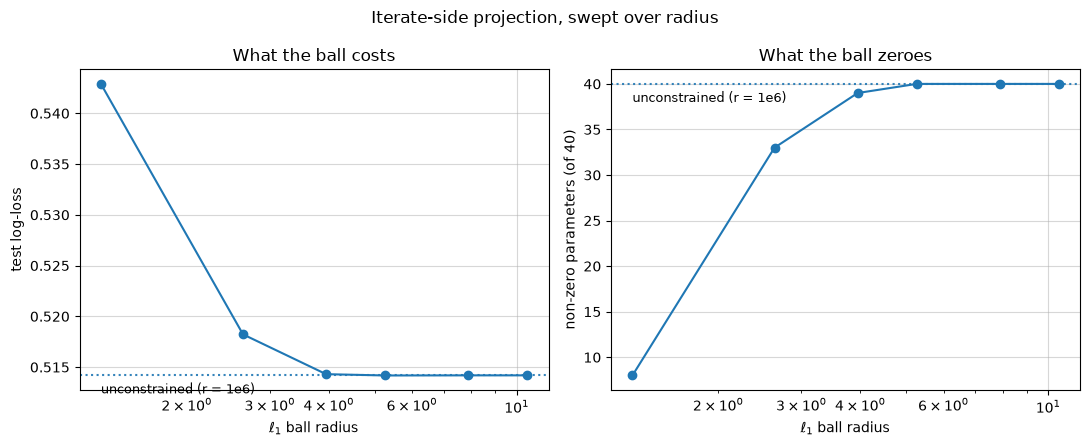

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for axis, values, reference, ylabel, title in (
    (axes[0], SWEEP_LOSS, WIDE.loss, "test log-loss",
     "What the ball costs"),
    (axes[1], SWEEP_NNZ, WIDE.nnz, f"non-zero parameters (of {D_TOTAL})",
     "What the ball zeroes"),
):
    axis.plot(SWEEP_RADII, values, marker="o",
             )
    axis.axhline(reference, linestyle=":", alpha=0.9)
    axis.annotate("unconstrained (r = 1e6)", xy=(SWEEP_RADII[0], reference),
                  xytext=(0, -13), textcoords="offset points",
                  fontsize=9)
    axis.set_xscale("log")
    axis.set_xlabel(r"$\ell_1$ ball radius")
    axis.set_ylabel(ylabel)
    axis.set_title(title)
    axis.grid(alpha=0.5)

fig.suptitle("Iterate-side projection, swept over radius")
fig.tight_layout()
plt.show()

### Reading the sweep

The cost is flat until the ball is genuinely tight and then rises sharply. At
`r = 3.9451` (0.75× the control's norm) log-loss is 0.5143 against the
unconstrained 0.5142 and 39 of 40 parameters survive; at 2.6301 the ball costs
0.0040 and 7 parameters; at 1.3150 it costs 0.0287 and leaves 8 of 40.

At exactly 1.0× the control's norm the projection still binds slightly —
`‖θ‖₁` lands at 5.2476 rather than 5.2602 — because the ball constrains the
whole trajectory, not just the endpoint, and a path that would have wandered
outside it is bent. Above 1.5× the returned norm is the control's 5.2602 to
four decimals. This is the ordinary shrinkage curve: the ℓ₁ ball buys sparsity
and pays in fit, and since the projection is post-processing, **what it costs
is a statement about constrained optimization, not about the mechanism**.

The same constraint over time rather than at the end: `‖θ_t‖₁` at every step
for three arms — the control, the iterate-projected arm at the binding radius,
and the estimate-projected arm at the forced radius. Two runs, since the
control's trajectory is already recorded, and the third series is what makes
the duality visible in one frame.

two recorded runs in 19.8s



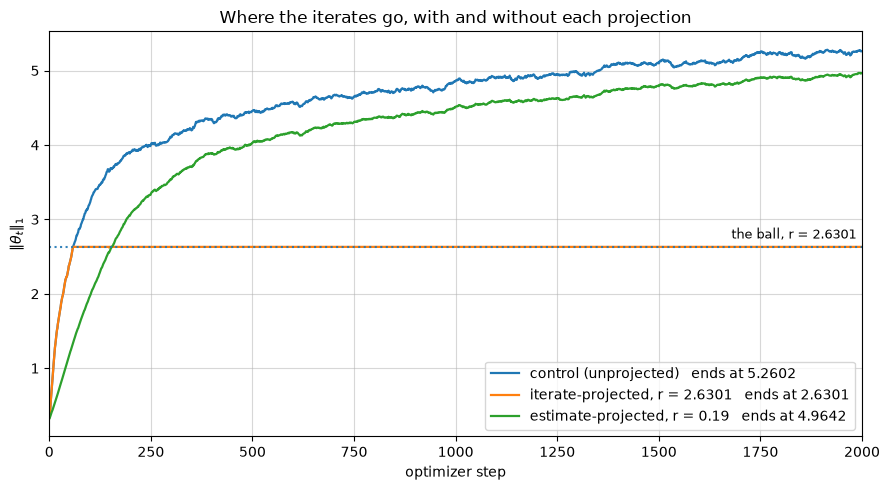

the iterate-projected arm first reaches its ball at step 59 and is pinned to it for the remaining 1,941 steps


In [30]:
t0 = time.time()
# Only the iterate stream is wanted here; section 4 already has the released
# one for the control, and it is the same mechanism in every arm.
iterate_iter, iterate_est = [], []
run_arm(optimizer=recording(
    l1_projected(updates.sgd(LEARNING_RATE), RADIUS_ITER), [], iterate_iter))
run_arm(optimizer=recording(
    l1_projected_estimate(updates.sgd(LEARNING_RATE), RADIUS_BINDING),
    [], iterate_est))
print(f"two recorded runs in {time.time() - t0:.1f}s\n")

TRAJECTORY = {
    "control": TRAJECTORY_CONTROL,
    "iterate-projected": np.array([float(v) for v in iterate_iter]),
    "estimate-projected": np.array([float(v) for v in iterate_est]),
}
steps_axis = np.arange(1, STEPS + 1)

fig, axis = plt.subplots(figsize=(9, 5))
for name, label in (
    ("control", "control (unprojected)"),
    ("iterate-projected", f"iterate-projected, r = {RADIUS_ITER:.4f}"),
    ("estimate-projected",
     f"estimate-projected, r = {RADIUS_BINDING}"),
):
    axis.plot(steps_axis, TRAJECTORY[name],
              linewidth=1.6, label=f"{label}   ends at "
                                   f"{TRAJECTORY[name][-1]:.4f}")

axis.axhline(RADIUS_ITER, linestyle=":", alpha=0.9)
axis.annotate(f"the ball, r = {RADIUS_ITER:.4f}", xy=(STEPS, RADIUS_ITER),
              xytext=(-4, 6), textcoords="offset points", ha="right",
              fontsize=9)

first_bind = int(np.argmax(TRAJECTORY["iterate-projected"]
                           >= RADIUS_ITER - 1e-4)) + 1
axis.set_xlabel("optimizer step")
axis.set_ylabel(r"$\|\theta_t\|_1$")
axis.set_xlim(0, STEPS)
axis.set_title("Where the iterates go, with and without each projection")
axis.legend(loc="lower right")
axis.grid(alpha=0.5)
fig.tight_layout()
plt.show()

print(f"the iterate-projected arm first reaches its ball at step "
      f"{first_bind} and is pinned to it for the remaining "
      f"{STEPS - first_bind:,} steps")

### Reading the trajectory

The iterate-projected arm climbs with the control for the first 58 steps, hits
the ball at step 59, and is **pinned to it exactly for the remaining 1,941** —
every subsequent step is a descent step followed by a projection back onto the
boundary.

The control and the estimate-projected arm climb past it and separate from each
other only slightly, ending at 5.2602 against 4.9642: projecting the *estimate*
at a radius 2.1× below the released norm rescales each step a little and
produces a slightly damped copy of the control's trajectory rather than a
constrained one. **Same wrapper argument, same seam, categorically different
object constrained.** Note also that the control's norm is still rising at step
2,000 — nothing here has converged.

## What this shows, and what it does not

**The comparison.** DP-SGD on Criteo at ε = 3, δ = 1e-6 over 2,000 steps,
against the same run with each of the two ℓ₁ projections inserted at the
optimizer seam. Every arm shares an initialization, both random streams, `C`,
`η`, `L`, σ and therefore ε; the optimizer object is the only difference.

**The finding is two-sided.** Constraining the *iterates* costs what
constraining iterates costs: at half the control's norm, 0.0040 log-loss and
0.0124 PR-AUC, with 7 of 40 parameters zeroed, and section 6 traces the whole
shrinkage curve — flat until the ball is tight, then steep. Constraining the
*estimate* does nothing at any radius with a principle behind it: identical to
the control at the paper's `C·√d = 31.62`, and worth 0.0001 log-loss when
forced 2.1× below what the mechanism releases. Section 4 measures the reason —
`‖g̃‖₁ ≈ 0.41` against a ball of 31.62, the identity map with 1.9 decades to
spare. Lemma 3.1 wants sparse per-example gradients, and a dense 40-feature
logistic model has none.

Not shown, and not claimed:

- Both wrappers are post-processing, so every arm carries DP-SGD's own ε and no
  other. That ε is RDP's (ADR-0011); PLD would report a smaller one.
- This is the paper's projection *step* at the optimizer seam (ADR-0014,
  ADR-0015), not its standalone sparse-gradient mechanism.
- One seed, no error bars; the estimate side's 0.0001 is well inside what a
  second seed would move.
- 2,000 steps: `‖θ‖₁` is still climbing at the last one, so every radius here
  is scaled off a control that has not converged.
- Preprocessing is unaccounted (ADR-0008), and the ε covers the training loop
  only.
- One dataset, one model — logistic regression on Criteo, 39 dense features.
  A sparse problem is where the estimate-side transform would earn its place.